In [41]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

Key insights need to be take care of -

>What is the most frequent genre of movies released on Netflix?

>Which has highest votes in vote avg column?

>What movie got the highest popularity? what's its genre?

>What movie got the lowest popularity? what's its genre?

>Which year has the most filmmed movies?


In [42]:
df = pd.read_csv('mymoviedb.csv' , lineterminator = '\n')

In [43]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


Work need to be done 

> dataset contains 9827 rows and 9 columns.

> convert the data type of Release_Date from str to date_time and extract year from it for better analysis.

> remove whitespaces from genre
 
> Drop  - Original_Language ,  Poster_Url & Overview cause they are useless in our case if we carefully make a observation on it.
 

In [46]:
df['Genre'].head()
#  remove the whitespace 

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [48]:
print(df.duplicated().sum())

0


In [7]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [8]:
# Preprocessing begins 
# conversion of dtype of date 
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtype)

datetime64[ns]


In [9]:
df['Release_Date'] = df['Release_Date'].dt.year

In [10]:
df.head(3)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...


In [11]:
# Dropping the columns 

cols = ['Overview','Original_Language','Poster_Url']
df.drop(cols,axis = 1,inplace = True)
df.head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


**Label the Vote_Average column in different forms**

Let's convert the `Vote_Average` column in different labels like `Popular`,`Average`,`Below Average`,`Not Popular` with the help of a function name
`categorization_col` given below - 

In [12]:
def categorization_col(df,col,labels):

    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    df[col] = pd.cut(df[col],edges,labels = labels,duplicates = 'drop') #cut function is used to done this kind of work
    return df

In [13]:
labels = ['Not Popular','Below Average','Average','Popular']

categorization_col(df,'Vote_Average',labels)

df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below Average,Thriller
3,2021,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War"


In [14]:
df['Vote_Average'].unique()

['Popular', 'Below Average', 'Average', 'Not Popular', NaN]
Categories (4, object): ['Not Popular' < 'Below Average' < 'Average' < 'Popular']

In [15]:
df['Vote_Average'].value_counts()
df.info()
# Here see there are some Nan present in Vote_Average column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  9827 non-null   int32   
 1   Title         9827 non-null   object  
 2   Popularity    9827 non-null   float64 
 3   Vote_Count    9827 non-null   int64   
 4   Vote_Average  9727 non-null   category
 5   Genre         9827 non-null   object  
dtypes: category(1), float64(1), int32(1), int64(1), object(2)
memory usage: 355.4+ KB


In [16]:
df.isna().sum()
# cause edge works like (x,y] formate means x will be excluded and and values > x and <= y will be included 

Release_Date      0
Title             0
Popularity        0
Vote_Count        0
Vote_Average    100
Genre             0
dtype: int64

In [17]:
df.dropna(inplace = True)


In [18]:
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

 **here we will handle whitespaces of genre , and will separate it into separate rows for same data but different genre for better analysis**

In [19]:
# split the diffrent genre into a list with repsect to ', '
df['Genre'] = df['Genre'].str.split(', ')

In [20]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"[Action, Adventure, Science Fiction]"
1,2022,The Batman,3827.658,1151,Popular,"[Crime, Mystery, Thriller]"
2,2022,No Exit,2618.087,122,Below Average,[Thriller]
3,2021,Encanto,2402.201,5076,Popular,"[Animation, Comedy, Family, Fantasy]"
4,2021,The King's Man,1895.511,1793,Average,"[Action, Adventure, Thriller, War]"


In [21]:
# now explode function will do the rest of the work
df = df.explode('Genre').reset_index(drop = True)

In [22]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [23]:
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


**Data Visualisation**

# What is the most frequent genre of movies released on Netflix?

In [25]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

In [26]:
sns.set_style('darkgrid')

<Axes: xlabel='count', ylabel='Genre'>

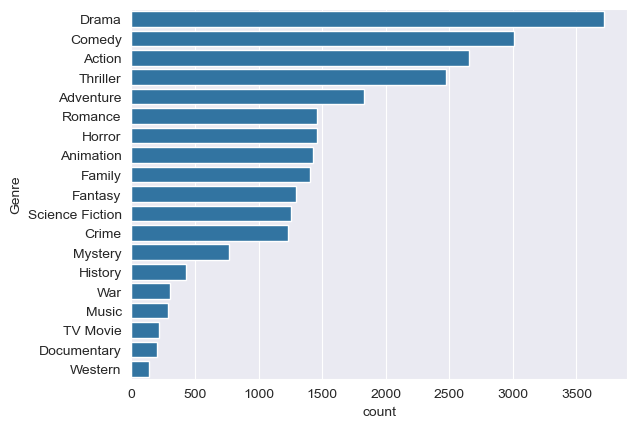

In [27]:
# by countplot
sns.countplot(y = 'Genre',data = df,order = df['Genre'].value_counts().index)

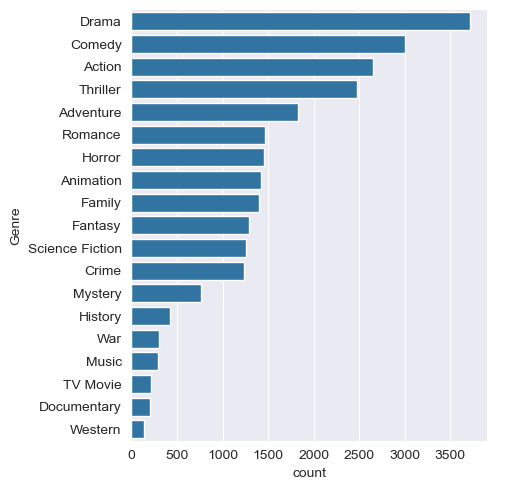

In [28]:
# by catplot
sns.catplot(y = 'Genre' , data = df, kind = 'count',order = df['Genre'].value_counts().index)

# Which has highest votes in vote avg column?

<Axes: xlabel='count', ylabel='Vote_Average'>

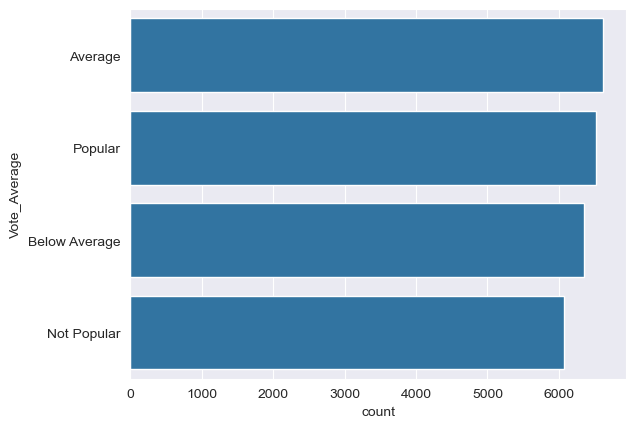

In [29]:
sns.countplot(y = 'Vote_Average',data = df,order = df['Vote_Average'].value_counts().index) # use y instead x incase you want it to be horizontal

# What movie got the highest popularity? what's its genre?

In [30]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction


# What movie got the lowest popularity? what's its genre?

In [31]:
df[df['Popularity'] == df['Popularity'].min()]
# “Keep rows where the condition is True”

# So Pandas returns all rows whose popularity equals the lowest value

# df[df[]] condition inside a dataframe 

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,Average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,Average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,Average,History
25549,1984,Threads,13.354,186,Popular,War
25550,1984,Threads,13.354,186,Popular,Drama
25551,1984,Threads,13.354,186,Popular,Science Fiction


# Which year has the most filmmed movies?

In [32]:
# since we have exploded the datafram with 'Genre' so we need to check only unique movie per year

In [33]:
# dont use hist() here cause it only use when we need to show distribution in ranges like 2000-2005 etc

In [34]:
# but currently we using it cause it is easier to use at the very first 

<Axes: >

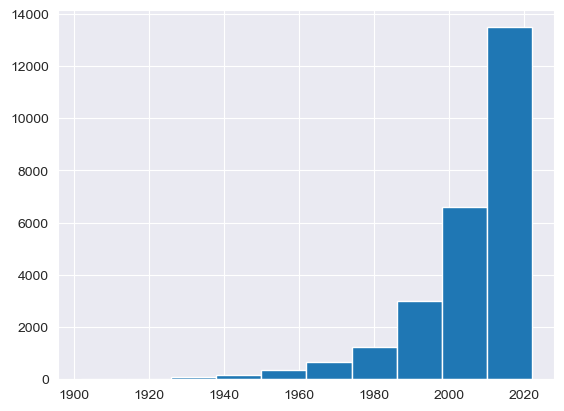

In [35]:
df['Release_Date'].hist()

In [36]:
# nunique() → “How many distinct values are there?”
movies = (df.groupby('Release_Date')['Title'].nunique().sort_values(ascending = False))

In [37]:
movies.columns = ['Year','Total']

In [38]:
movies.head(1)

Release_Date
2021    711
Name: Title, dtype: int64

In [39]:
# Does it convert a Series to a DataFrame?
# .reset_index()
# ✅ YES — when used on a Series

movies = movies.head(10).reset_index()
movies.columns = ['Year','Total_movies']

<Axes: xlabel='Year', ylabel='Total_movies'>

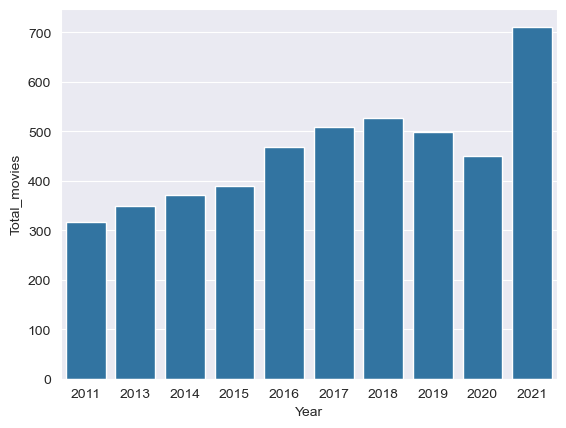

In [40]:
sns.barplot(x = 'Year',y = 'Total_movies', data = movies)

# 2021 is the right answer t